## MD Dataset Discovery and Trajectory Loading

This code scans the molecular dynamics dataset directory and automatically identifies all available simulation systems. The expected directory structure is organized by variant, condition and replicate, where each replicate consists of a matching trajectory file (`md_center_*.xtc`) and topology/structure file (`md_center_*.pdb`).

For every valid PDB–XTC pair, the code extracts the variant name, condition and replicate number from the folder and file names. It then loads the corresponding trajectory with `MDAnalysis.Universe` and prints basic metadata such as the number of atoms and trajectory frames.

This step is relevant because it verifies that all simulations are accessible, correctly paired and structurally readable before downstream analyses are performed. It also establishes the dataset organization used throughout the notebook, allowing subsequent analyses to be applied consistently across variants, substrate conditions and independent replicates.

In [ ]:
from pathlib import Path
import re
import MDAnalysis as mda


SCRIPT_DIR = Path("/home/dwp46550/ba_nylon/Notebooks/MD_data_loading.ipynb").resolve().parent


PROJECT_ROOT = SCRIPT_DIR.parent


base = PROJECT_ROOT / "data" / "md"

print(f"Using MD directory: {base}")

for variant_dir in base.iterdir():

    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name
    print(variant)
    for condition_dir in variant_dir.iterdir():

        if not condition_dir.is_dir():
            continue

        condition = condition_dir.name
        print(condition)
        for xtc_file in sorted(condition_dir.glob("md_center_*.xtc")):

            match = re.search(r"md_center_(\d+)", xtc_file.stem)

            if match is None:
                print(f"Could not detect replicate number from {xtc_file.name}")
                continue

            replicate = int(match.group(1))

            pdb_file = condition_dir / f"md_center_{replicate}.pdb"

            if not pdb_file.exists():
                print(f"Missing matching PDB for {xtc_file.name}")
                continue

            print("\n==============================")
            print(f"Variant: {variant}")
            print(f"Condition: {condition}")
            print(f"Replicate: {replicate}")
            print(f"PDB: {pdb_file.name}")
            print(f"XTC: {xtc_file.name}")

            u = mda.Universe(
                str(pdb_file),
                str(xtc_file)
            )

            print(f"Atoms: {u.atoms.n_atoms}")
            print(f"Frames: {len(u.trajectory)}")
            print("==============================")

Using MD directory: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/data/md
f134w_d304m_r330a
ace_coo

Variant: f134w_d304m_r330a
Condition: ace_coo
Replicate: 1
PDB: md_center_1.pdb
XTC: md_center_1.xtc
Atoms: 19385
Frames: 7501

Variant: f134w_d304m_r330a
Condition: ace_coo
Replicate: 2
PDB: md_center_2.pdb
XTC: md_center_2.xtc
Atoms: 19385
Frames: 7501

Variant: f134w_d304m_r330a
Condition: ace_coo
Replicate: 3
PDB: md_center_3.pdb
XTC: md_center_3.xtc
Atoms: 19385
Frames: 7501
WT
coo_ace

Variant: WT
Condition: coo_ace
Replicate: 1
PDB: md_center_1.pdb
XTC: md_center_1.xtc
Atoms: 19405
Frames: 7501

Variant: WT
Condition: coo_ace
Replicate: 2
PDB: md_center_2.pdb
XTC: md_center_2.xtc
Atoms: 19405
Frames: 7501

Variant: WT
Condition: coo_ace
Replicate: 3
PDB: md_center_3.pdb
XTC: md_center_3.xtc
Atoms: 19405
Frames: 7501
ace_coo

Variant: WT
Condition: ace_coo
Replicate: 1
PDB: md_center_1.pdb
XTC: md_center_1.xtc
Atoms: 19405
Frames: 7501

Variant: WT
Condition: ace_coo
Replicate: 2
PDB:

## Backbone RMSD Analysis Across Variants, Conditions and Replicates

This code calculates the backbone root mean square deviation (RMSD) for every MD trajectory in the dataset. The trajectories are automatically discovered from the project directory structure, grouped by NylC variant, substrate condition and replicate.

For each replicate, the protein backbone is aligned to the initial reference frame and the RMSD is calculated over the trajectory using a defined stride. The resulting frame-wise RMSD values are stored together with metadata describing the variant, condition, replicate and atom selection.

The code then generates three levels of RMSD output:

1. `rmsd_framewise.csv`: RMSD values for every analyzed frame.
2. `rmsd_replicate.csv`: summary statistics for each individual replicate, including mean, standard deviation, minimum and maximum RMSD.
3. `rmsd_variant_by_condition.csv`: replicate-averaged RMSD summaries for each variant and condition.

This analysis is relevant because backbone RMSD provides a first quality-control measure for global structural stability. It helps identify whether a simulation remains structurally stable, whether individual replicates show abnormal drift, and whether specific variants or substrate conditions induce stronger global conformational changes. In the context of the catalytic competence filter, RMSD is not interpreted as a direct activity predictor, but as an essential stability descriptor that ensures downstream mechanistic features are calculated from physically reasonable trajectories.

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt


SCRIPT_DIR = Path("/home/dwp46550/ba_nylon/Notebooks/MD_data_loading.ipynb").resolve().parent
PROJECT_ROOT = SCRIPT_DIR.parent
BASE = PROJECT_ROOT / "data" / "md"

OUT_DIR = PROJECT_ROOT / "results" / "md_feature_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STRIDE = 10

print(f"Using MD directory: {BASE}")


def compute_rmsd_for_replicate(
    u,
    variant,
    condition,
    replicate,
    select="protein and backbone",
    ref_frame=0,
    stride=10,
):
    ref = u.copy()
    ref.trajectory[ref_frame]

    if u.select_atoms(select).n_atoms == 0:
        raise ValueError(f"Selection returned 0 atoms: {select}")

    rmsd_analysis = rms.RMSD(
        u,
        ref,
        select=select,
        ref_frame=ref_frame,
    )

    rmsd_analysis.run(step=stride)

    df = pd.DataFrame(
        rmsd_analysis.results.rmsd,
        columns=["frame_index", "time_ps", "rmsd_A"],
    )

    df["variant"] = variant
    df["condition"] = condition
    df["replicate"] = replicate
    df["selection"] = select

    return df[
        [
            "variant",
            "condition",
            "replicate",
            "selection",
            "frame_index",
            "time_ps",
            "rmsd_A",
        ]
    ]


all_rmsd = []

for variant_dir in BASE.iterdir():

    if not variant_dir.is_dir():
        continue

    variant = variant_dir.name

    for condition_dir in variant_dir.iterdir():

        if not condition_dir.is_dir():
            continue

        condition = condition_dir.name

        for xtc_file in sorted(condition_dir.glob("md_center_*.xtc")):

            match = re.search(r"md_center_(\d+)", xtc_file.stem)

            if match is None:
                print(f"Could not detect replicate number from {xtc_file.name}")
                continue

            replicate = int(match.group(1))
            pdb_file = condition_dir / f"md_center_{replicate}.pdb"

            if not pdb_file.exists():
                print(f"Missing matching PDB for {xtc_file.name}")
                continue

            print(f"Processing: {variant} | {condition} | replicate {replicate}")

            u = mda.Universe(str(pdb_file), str(xtc_file))

            rmsd_df = compute_rmsd_for_replicate(
                u=u,
                variant=variant,
                condition=condition,
                replicate=replicate,
                select="protein and backbone",
                ref_frame=0,
                stride=STRIDE,
            )

            all_rmsd.append(rmsd_df)


rmsd_framewise = pd.concat(all_rmsd, ignore_index=True)
rmsd_framewise.to_csv(OUT_DIR / "rmsd_framewise.csv", index=False)

rmsd_replicate = (
    rmsd_framewise
    .groupby(["variant", "condition", "replicate"], as_index=False)
    .agg(
        rmsd_mean_A=("rmsd_A", "mean"),
        rmsd_std_A=("rmsd_A", "std"),
        rmsd_min_A=("rmsd_A", "min"),
        rmsd_max_A=("rmsd_A", "max"),
        n_frames=("rmsd_A", "count"),
    )
)

rmsd_replicate.to_csv(OUT_DIR / "rmsd_replicate.csv", index=False)

rmsd_variant_by_condition = (
    rmsd_replicate
    .groupby(["condition", "variant"], as_index=False)
    .agg(
        rmsd_mean_over_replicates_A=("rmsd_mean_A", "mean"),
        rmsd_sd_between_replicates_A=("rmsd_mean_A", "std"),
        n_replicates=("replicate", "count"),
    )
)

rmsd_variant_by_condition.to_csv(
    OUT_DIR / "rmsd_variant_by_condition.csv",
    index=False,
)

print(rmsd_variant_by_condition)

Using MD directory: /rwthfs/rz/cluster/home/dwp46550/ba_nylon/data/md
Processing: f134w_d304m_r330a | ace_coo | replicate 1
Processing: f134w_d304m_r330a | ace_coo | replicate 2
Processing: f134w_d304m_r330a | ace_coo | replicate 3
Processing: WT | coo_ace | replicate 1
Processing: WT | coo_ace | replicate 2
Processing: WT | coo_ace | replicate 3
Processing: WT | ace_coo | replicate 1
Processing: WT | ace_coo | replicate 2
Processing: WT | ace_coo | replicate 3
Processing: WT | no_substrate | replicate 1
Processing: WT | no_substrate | replicate 2
Processing: WT | no_substrate | replicate 3
Processing: D99R_f134w_d304m_r330a | ace_coo | replicate 1
Processing: D99R_f134w_d304m_r330a | ace_coo | replicate 2
Processing: D99R_f134w_d304m_r330a | ace_coo | replicate 3
Processing: D99R | no_substrate | replicate 1
Processing: D99R | no_substrate | replicate 2
Processing: D99R | no_substrate | replicate 3
      condition                 variant  rmsd_mean_over_replicates_A  \
0       ace_coo

## Frame-Wise RMSD Time Course Visualization

This code visualizes the backbone RMSD over simulation time for each NylC variant, substrate condition and replicate.

The first plotting block generates separate RMSD time-course plots for each variant within each condition. Each replicate is shown as an individual line, allowing direct inspection of replicate-to-replicate consistency and potential trajectory-specific deviations.

The second plotting block combines all variants and replicates within the same condition into a single plot. This provides a broader overview of how the structural stability of different variants compares under identical substrate conditions.

This analysis is relevant because RMSD time courses reveal whether a trajectory equilibrates, remains stable, or shows continuous structural drift. Unlike summary statistics alone, time-resolved RMSD plots can identify problematic replicates, late-stage conformational shifts, or transient instability. In the context of downstream feature extraction, this is an important quality-control step to ensure that catalytic geometry, substrate contacts and pocket features are interpreted only for structurally meaningful simulations.

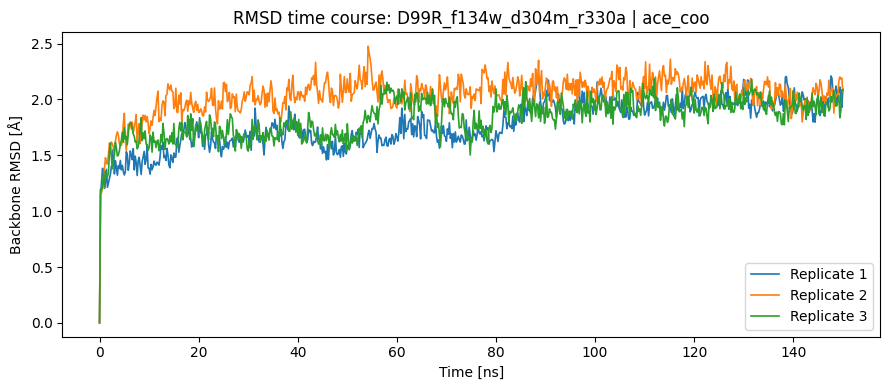

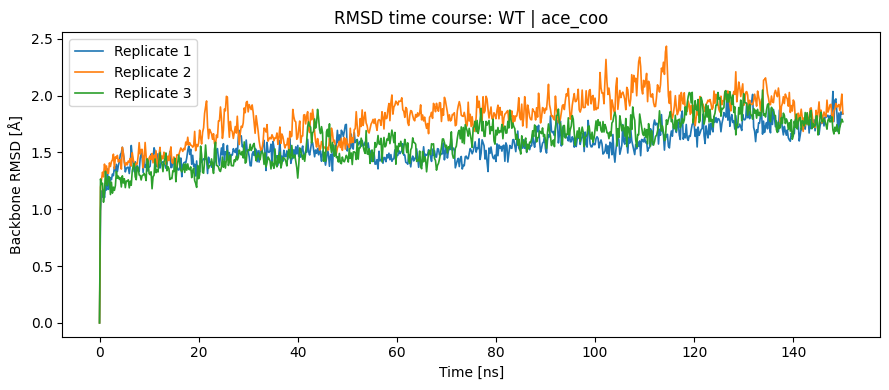

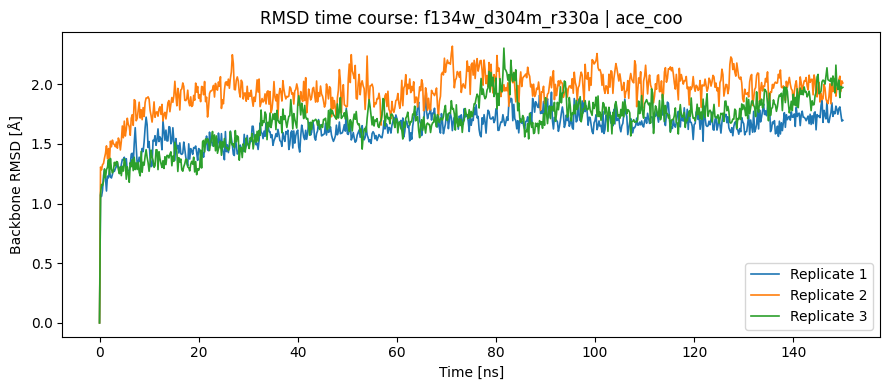

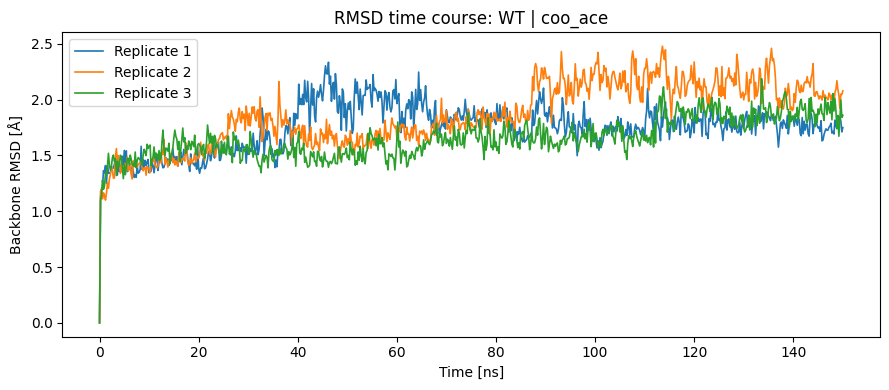

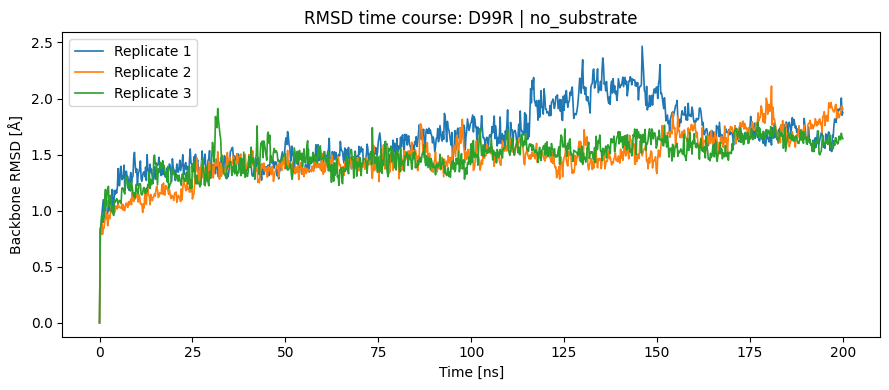

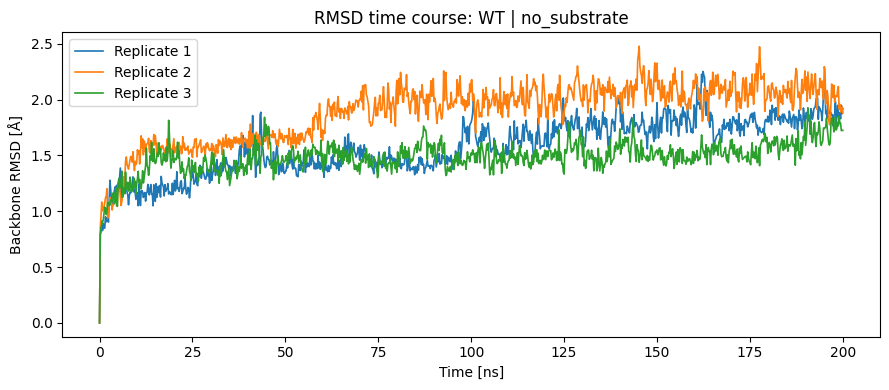

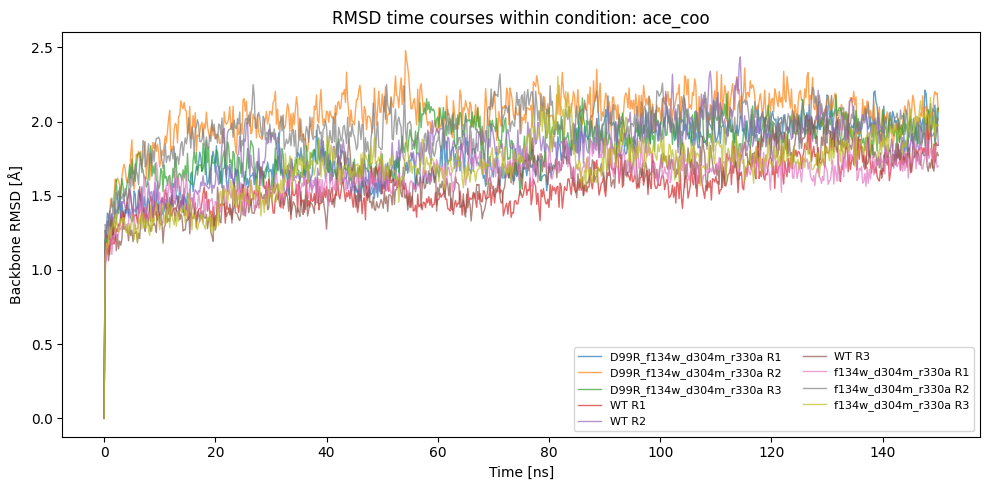

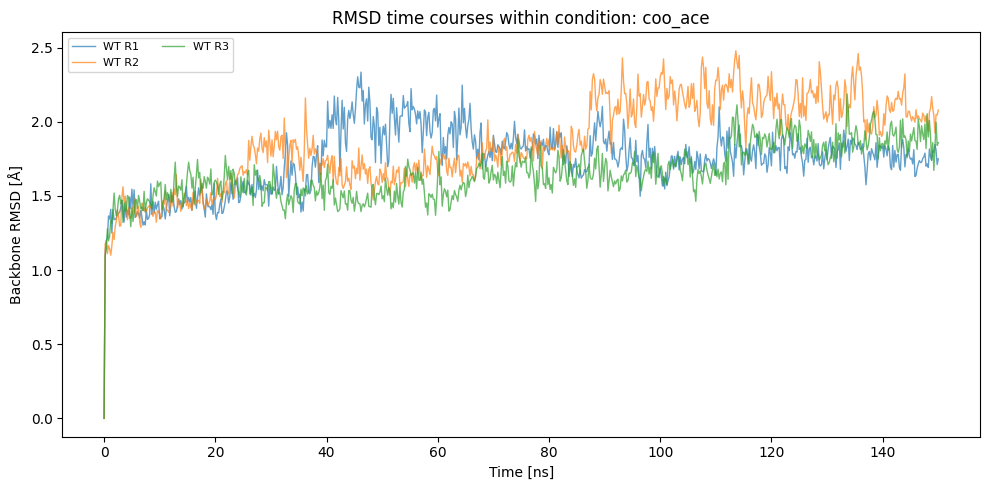

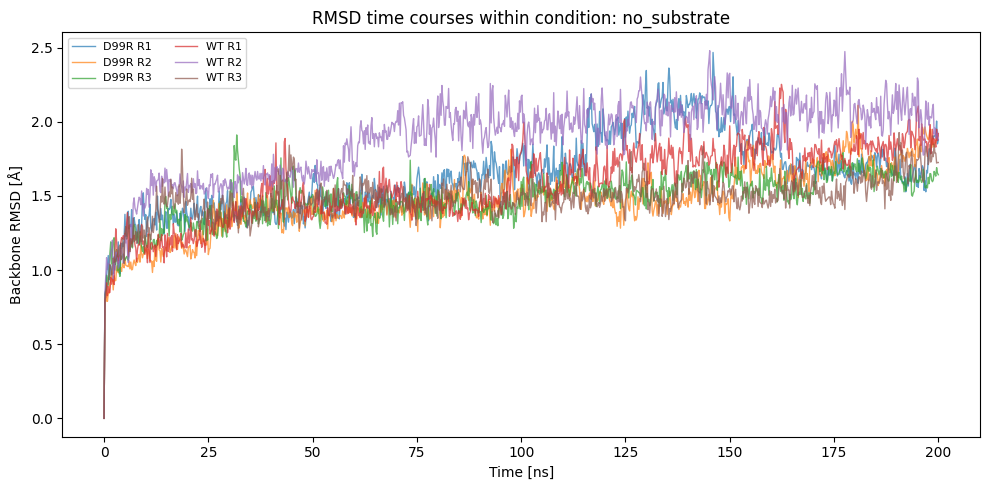

,condition,variant,replicate,time_ps,time_ns,rmsd_A
0,ace_coo,D99R_f134w_d304m_r330a,1,0.0,0.0,0.000001
1,ace_coo,D99R_f134w_d304m_r330a,1,200.0,0.2,1.138958
2,ace_coo,D99R_f134w_d304m_r330a,1,400.0,0.4,1.253946
3,ace_coo,D99R_f134w_d304m_r330a,1,600.0,0.6,1.383366
4,ace_coo,D99R_f134w_d304m_r330a,1,800.0,0.8,1.366495


(15018, 6)
18 trajectories


In [6]:
import matplotlib.pyplot as plt

conditions = sorted(rmsd_framewise["condition"].unique())

for condition_name in conditions:

    condition_df = rmsd_framewise[
        rmsd_framewise["condition"] == condition_name
    ].copy()

    variants = sorted(condition_df["variant"].unique())

    for variant in variants:

        plot_df = condition_df[
            condition_df["variant"] == variant
        ].copy()

        plt.figure(figsize=(9, 4))

        for replicate in sorted(plot_df["replicate"].unique()):

            rep_df = plot_df[
                plot_df["replicate"] == replicate
            ].sort_values("time_ps")

            plt.plot(
                rep_df["time_ps"] / 1000,
                rep_df["rmsd_A"],
                label=f"Replicate {replicate}",
                linewidth=1.2,
            )

        plt.xlabel("Time [ns]")
        plt.ylabel("Backbone RMSD [Å]")
        plt.title(f"RMSD time course: {variant} | {condition_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

for condition_name in sorted(rmsd_framewise["condition"].unique()):

    plot_df = rmsd_framewise[
        rmsd_framewise["condition"] == condition_name
    ].copy()

    plt.figure(figsize=(10, 5))

    for (variant, replicate), group in plot_df.groupby(["variant", "replicate"]):

        group = group.sort_values("time_ps")

        plt.plot(
            group["time_ps"] / 1000,
            group["rmsd_A"],
            linewidth=1,
            alpha=0.7,
            label=f"{variant} R{replicate}",
        )

    plt.xlabel("Time [ns]")
    plt.ylabel("Backbone RMSD [Å]")
    plt.title(f"RMSD time courses within condition: {condition_name}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    df_rmsd = rmsd_framewise.copy()

# Convert time from ps to ns
df_rmsd["time_ns"] = df_rmsd["time_ps"] / 1000

# Keep only relevant columns for plateau analysis
df_rmsd = df_rmsd[
    [
        "condition",
        "variant",
        "replicate",
        "time_ps",
        "time_ns",
        "rmsd_A",
    ]
].copy()

# Remove missing values
df_rmsd = df_rmsd.dropna(
    subset=[
        "condition",
        "variant",
        "replicate",
        "time_ns",
        "rmsd_A",
    ]
)

# Sort properly
df_rmsd = df_rmsd.sort_values(
    [
        "condition",
        "variant",
        "replicate",
        "time_ns",
    ]
).reset_index(drop=True)

# Optional alias, falls du den Namen dr_rmsd verwenden willst
dr_rmsd = df_rmsd.copy()

display(df_rmsd.head())
print(df_rmsd.shape)
print(df_rmsd[["condition", "variant", "replicate"]].drop_duplicates().shape[0], "trajectories")

### Plateau detection of frame wise RMSD time courses

This code cell determines the earliest time point at which the backbone RMSD time course can be interpreted as having reached a plateau for each simulation condition, variant, and replicate. The aim is to derive a conservative estimate of the minimum required simulation duration from the RMSD trajectories.

The analysis is based on sliding window regression. For each trajectory, multiple window sizes are evaluated (`10`, `20`, and `25 ns`). Within each window, a linear regression of the form

`RMSD = intercept + slope · time`

is fitted. The local slope is used as a measure of systematic RMSD drift. A plateau is assumed if, from a given candidate time onward, the subsequent windows show only weak local drift, stable window means, and approximately constant window standard deviations.

The plateau criteria used in this analysis are:

`|slope| < 0.005 Å/ns`

`max(window means) - min(window means) < 0.25 Å`

`max(window standard deviations) - min(window standard deviations) < 0.20 Å`

At least `80%` of all subsequent windows must satisfy the slope criterion. This avoids rejecting a plateau solely because of individual noisy windows.

The evaluation is performed hierarchically and conservatively. First, a plateau time is determined for each combination of condition, variant, replicate, and window size. For each replicate, the latest plateau time across all window sizes is selected. For each variant, the latest plateau time across all replicates is selected. For each condition, the latest plateau time across all variants is selected. Therefore, the estimated minimum simulation duration is not determined by the fastest stabilizing trajectory, but by the trajectory within each group that reaches a stable RMSD plateau latest.

The main output tables are:

`df_window_plateaus`: plateau times for each window size and replicate

`df_replicate_plateaus`: conservative plateau times for each replicate

`df_variant_plateaus`: conservative plateau times for each variant within each condition

`df_condition_plateaus`: estimated minimum simulation duration for each condition

`global_min_simulation_duration_ns`: conservative global minimum simulation duration across all conditions

In [10]:
from scipy.stats import linregress


# ============================================================
# Input dataframe
# ============================================================

df = df_rmsd.copy()

condition_col = "condition"
variant_col = "variant"
replicate_col = "replicate"
time_col = "time_ns"
rmsd_col = "rmsd_A"


# ============================================================
# Plateau parameters
# ============================================================

window_sizes = [10, 20, 25]      # ns
step_size = 1                    # ns

slope_threshold = 0.005          # Angstrom/ns
mean_threshold = 0.25            # Angstrom
std_threshold = 0.20             # Angstrom

min_fraction_windows_ok = 0.80
min_points_per_window = 5


# ============================================================
# Basic checks
# ============================================================

required_cols = [
    condition_col,
    variant_col,
    replicate_col,
    time_col,
    rmsd_col,
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df = df.dropna(subset=required_cols).copy()

df = df.sort_values(
    [
        condition_col,
        variant_col,
        replicate_col,
        time_col,
    ]
).reset_index(drop=True)


# ============================================================
# Helper functions
# ============================================================

def fit_linear_regression(time_values, rmsd_values):
    """
    Fits RMSD = intercept + slope * time.
    """
    result = linregress(time_values, rmsd_values)

    return {
        "intercept": result.intercept,
        "slope": result.slope,
        "r_value": result.rvalue,
        "p_value": result.pvalue,
        "std_err": result.stderr,
    }


def get_windows_after_candidate(time, rmsd, candidate_time, window_size, step_size):
    """
    Returns all sliding windows from candidate_time until the end of the trajectory.
    """
    max_time = np.max(time)

    window_starts = np.arange(
        candidate_time,
        max_time - window_size + step_size,
        step_size,
    )

    windows = []

    for start in window_starts:
        end = start + window_size

        mask = (time >= start) & (time < end)

        if np.sum(mask) >= min_points_per_window:
            windows.append((time[mask], rmsd[mask], start, end))

    return windows


def evaluate_candidate_plateau(time, rmsd, candidate_time, window_size):
    """
    Tests whether the RMSD is plateau-like from candidate_time onward.
    """
    windows = get_windows_after_candidate(
        time=time,
        rmsd=rmsd,
        candidate_time=candidate_time,
        window_size=window_size,
        step_size=step_size,
    )

    if len(windows) < 2:
        return {
            "plateau": False,
            "fraction_slope_ok": np.nan,
            "mean_range": np.nan,
            "std_range": np.nan,
            "n_windows": len(windows),
        }

    slopes = []
    means = []
    stds = []

    for window_time, window_rmsd, start, end in windows:
        fit = fit_linear_regression(window_time, window_rmsd)

        slopes.append(fit["slope"])
        means.append(np.mean(window_rmsd))
        stds.append(np.std(window_rmsd, ddof=1))

    slopes = np.array(slopes)
    means = np.array(means)
    stds = np.array(stds)

    fraction_slope_ok = np.mean(np.abs(slopes) < slope_threshold)

    mean_range = np.max(means) - np.min(means)
    std_range = np.max(stds) - np.min(stds)

    slope_ok = fraction_slope_ok >= min_fraction_windows_ok
    mean_ok = mean_range < mean_threshold
    std_ok = std_range < std_threshold

    plateau = slope_ok and mean_ok and std_ok

    return {
        "plateau": plateau,
        "fraction_slope_ok": fraction_slope_ok,
        "mean_range": mean_range,
        "std_range": std_range,
        "n_windows": len(windows),
    }


def find_plateau_time(time, rmsd, window_size):
    """
    Finds the earliest candidate time from which the trajectory fulfills
    the plateau criteria.
    """
    time = np.asarray(time)
    rmsd = np.asarray(rmsd)

    min_time = np.min(time)
    max_time = np.max(time)

    candidate_times = np.arange(
        min_time,
        max_time - window_size + step_size,
        step_size,
    )

    candidate_results = []

    for candidate_time in candidate_times:
        result = evaluate_candidate_plateau(
            time=time,
            rmsd=rmsd,
            candidate_time=candidate_time,
            window_size=window_size,
        )

        result["candidate_time_ns"] = candidate_time
        result["window_size_ns"] = window_size

        candidate_results.append(result)

        if result["plateau"]:
            return candidate_time, pd.DataFrame(candidate_results)

    return None, pd.DataFrame(candidate_results)


# ============================================================
# Main analysis separated by condition
# ============================================================

all_candidate_results = []
window_results = []
replicate_results = []
variant_results = []
condition_results = []

for condition, df_condition in df.groupby(condition_col):

    condition_variant_plateau_times = []

    for variant, df_variant in df_condition.groupby(variant_col):

        variant_replicate_plateau_times = []

        for replicate, df_rep in df_variant.groupby(replicate_col):

            df_rep = df_rep.sort_values(time_col).copy()

            time = df_rep[time_col].values
            rmsd = df_rep[rmsd_col].values

            replicate_window_plateau_times = []

            for window_size in window_sizes:

                plateau_time, candidate_df = find_plateau_time(
                    time=time,
                    rmsd=rmsd,
                    window_size=window_size,
                )

                candidate_df[condition_col] = condition
                candidate_df[variant_col] = variant
                candidate_df[replicate_col] = replicate

                all_candidate_results.append(candidate_df)

                window_results.append({
                    condition_col: condition,
                    variant_col: variant,
                    replicate_col: replicate,
                    "window_size_ns": window_size,
                    "window_plateau_time_ns": plateau_time,
                })

                if plateau_time is not None:
                    replicate_window_plateau_times.append(plateau_time)

            if len(replicate_window_plateau_times) == 0:
                replicate_plateau_time = None
            else:
                replicate_plateau_time = max(replicate_window_plateau_times)

            replicate_results.append({
                condition_col: condition,
                variant_col: variant,
                replicate_col: replicate,
                "replicate_plateau_time_ns": replicate_plateau_time,
                "n_window_sizes_with_plateau": len(replicate_window_plateau_times),
                "n_window_sizes_total": len(window_sizes),
            })

            if replicate_plateau_time is not None:
                variant_replicate_plateau_times.append(replicate_plateau_time)

        if len(variant_replicate_plateau_times) == 0:
            variant_plateau_time = None
        else:
            variant_plateau_time = max(variant_replicate_plateau_times)

        variant_results.append({
            condition_col: condition,
            variant_col: variant,
            "variant_plateau_time_ns": variant_plateau_time,
            "n_replicates_with_plateau": len(variant_replicate_plateau_times),
            "n_replicates_total": df_variant[replicate_col].nunique(),
        })

        if variant_plateau_time is not None:
            condition_variant_plateau_times.append(variant_plateau_time)

    if len(condition_variant_plateau_times) == 0:
        condition_plateau_time = None
    else:
        condition_plateau_time = max(condition_variant_plateau_times)

    condition_results.append({
        condition_col: condition,
        "condition_min_simulation_duration_ns": condition_plateau_time,
        "n_variants_with_plateau": len(condition_variant_plateau_times),
        "n_variants_total": df_condition[variant_col].nunique(),
    })


# ============================================================
# Output tables
# ============================================================

if len(all_candidate_results) > 0:
    df_candidates = pd.concat(all_candidate_results, ignore_index=True)
else:
    df_candidates = pd.DataFrame()

df_window_plateaus = pd.DataFrame(window_results)
df_replicate_plateaus = pd.DataFrame(replicate_results)
df_variant_plateaus = pd.DataFrame(variant_results)
df_condition_plateaus = pd.DataFrame(condition_results)

valid_condition_plateaus = df_condition_plateaus[
    "condition_min_simulation_duration_ns"
].dropna()

if len(valid_condition_plateaus) == 0:
    global_min_simulation_duration_ns = None
else:
    global_min_simulation_duration_ns = valid_condition_plateaus.max()


# ============================================================
# Print summary
# ============================================================

print("Window-level plateau times:")
display(df_window_plateaus)

print("Replicate-level plateau times:")
display(df_replicate_plateaus)

print("Variant-level plateau times separated by condition:")
display(df_variant_plateaus)

print("Condition-level minimal simulation durations:")
display(df_condition_plateaus)

print("Global conservative minimal simulation duration across all conditions:")
print(global_min_simulation_duration_ns, "ns")


Window-level plateau times:


,condition,variant,replicate,window_size_ns,window_plateau_time_ns
0,ace_coo,D99R_f134w_d304m_r330a,1,10,NaN
1,ace_coo,D99R_f134w_d304m_r330a,1,20,74.0
2,ace_coo,D99R_f134w_d304m_r330a,1,25,73.0
3,ace_coo,D99R_f134w_d304m_r330a,2,10,NaN
4,ace_coo,D99R_f134w_d304m_r330a,2,20,128.0
5,ace_coo,D99R_f134w_d304m_r330a,2,25,33.0
6,ace_coo,D99R_f134w_d304m_r330a,3,10,138.0
7,ace_coo,D99R_f134w_d304m_r330a,3,20,75.0
8,ace_coo,D99R_f134w_d304m_r330a,3,25,54.0
9,ace_coo,WT,1,10,NaN


Replicate-level plateau times:


,condition,variant,replicate,replicate_plateau_time_ns,n_window_sizes_with_plateau,n_window_sizes_total
0,ace_coo,D99R_f134w_d304m_r330a,1,74.0,2,3
1,ace_coo,D99R_f134w_d304m_r330a,2,128.0,2,3
2,ace_coo,D99R_f134w_d304m_r330a,3,138.0,3,3
3,ace_coo,WT,1,119.0,2,3
4,ace_coo,WT,2,NaN,0,3
5,ace_coo,WT,3,134.0,1,3
6,ace_coo,f134w_d304m_r330a,1,28.0,2,3
7,ace_coo,f134w_d304m_r330a,2,76.0,2,3
8,ace_coo,f134w_d304m_r330a,3,NaN,0,3
9,coo_ace,WT,1,90.0,2,3


Variant-level plateau times separated by condition:


,condition,variant,variant_plateau_time_ns,n_replicates_with_plateau,n_replicates_total
0,ace_coo,D99R_f134w_d304m_r330a,138.0,3,3
1,ace_coo,WT,134.0,2,3
2,ace_coo,f134w_d304m_r330a,76.0,2,3
3,coo_ace,WT,130.0,3,3
4,no_substrate,D99R,189.0,3,3
5,no_substrate,WT,179.0,3,3


Condition-level minimal simulation durations:


,condition,condition_min_simulation_duration_ns,n_variants_with_plateau,n_variants_total
0,ace_coo,138.0,3,3
1,coo_ace,130.0,1,1
2,no_substrate,189.0,2,2


Global conservative minimal simulation duration across all conditions:
189.0 ns


### Plateau detection of block averaged frame wise RMSD time courses

This code cell determines the earliest time point at which each backbone RMSD trajectory can be interpreted as having reached a stable plateau. The analysis is performed separately for each simulation condition, variant, and replicate. The goal is to derive a conservative estimate of the minimum required simulation duration while reducing the influence of high frequency frame wise noise.

Before plateau detection, the frame wise RMSD trajectories are block averaged using a block size of `0.5 ns`. Within each block, the RMSD values are averaged. This reduces the influence of short time scale thermal fluctuations and decreases the effect of autocorrelation between neighboring MD frames. The resulting block averaged RMSD trajectory is then used for the sliding window analysis.

The plateau detection is based on sliding window regression. For each trajectory, multiple window sizes are evaluated (`10`, `20`, and `25 ns`). Within each window, a linear regression of the form

`RMSD = intercept + slope · time`

is fitted. The slope represents systematic RMSD drift within the window, while the residuals represent stochastic fluctuations around the local trend. A trajectory is considered plateau-like from a candidate time onward if the subsequent windows show no relevant systematic drift, stable window means, and approximately constant variance.

The plateau criteria used in this analysis are:

`|slope| < 0.005 Å/ns`

`max(window means) - min(window means) < 0.25 Å`

`max(window standard deviations) - min(window standard deviations) < 0.20 Å`

At least `80%` of all subsequent windows must satisfy the slope criterion. In addition, the code can optionally require that the approximate `95%` confidence interval of the local slope contains zero for at least `80%` of subsequent windows. This provides an additional check that the local drift is statistically compatible with zero. Since MD frames are temporally autocorrelated, this confidence interval is interpreted as a supportive diagnostic rather than as a strict independent statistical test.

The code also calculates residuals from each local regression. These residuals represent the remaining fluctuations after removing the local linear trend. An optional Shapiro-Wilk test can be used to check whether these residuals are compatible with Gaussian noise. However, this normality check is disabled by default because MD trajectories are autocorrelated and the assumption of independent residuals is only approximate. Therefore, residual normality is treated as a weak diagnostic and not as the main plateau criterion.

The evaluation is performed hierarchically and conservatively. First, a plateau time is determined for each combination of condition, variant, replicate, and window size. For each replicate, the latest plateau time across all tested window sizes is selected. For each variant, the latest plateau time across all replicates is selected. For each condition, the latest plateau time across all variants is selected. This ensures that the estimated minimum simulation duration is determined by the slowest stabilizing trajectory within each group, rather than by the fastest stabilizing replicate.

The main output tables are:

`df_rmsd_blocked`: block averaged RMSD trajectories used for plateau detection

`df_candidates`: all tested candidate plateau times and their corresponding diagnostic values

`df_window_plateaus`: plateau times for each window size and replicate

`df_replicate_plateaus`: conservative plateau times for each replicate

`df_variant_plateaus`: conservative plateau times for each variant within each condition

`df_condition_plateaus`: estimated minimum simulation duration for each condition

`global_min_simulation_duration_ns`: conservative global minimum simulation duration across all conditions

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, shapiro


# ============================================================
# Input dataframe
# ============================================================

df = df_rmsd.copy()

condition_col = "condition"
variant_col = "variant"
replicate_col = "replicate"
time_col = "time_ns"
rmsd_col = "rmsd_A"


# ============================================================
# Plateau parameters
# ============================================================

window_sizes = [10, 20, 25]        # ns
step_size = 1                      # ns

block_size_ns = 0.5                # ns
min_points_per_block = 2

slope_threshold = 0.005            # Angstrom/ns
mean_threshold = 0.25              # Angstrom
std_threshold = 0.20               # Angstrom

min_fraction_windows_ok = 0.80
min_points_per_window = 5

use_slope_ci = True
slope_ci_multiplier = 1.96         # approximate 95 percent CI

use_residual_normality_check = False
normality_alpha = 0.05
min_points_for_shapiro = 8


# ============================================================
# Basic checks
# ============================================================

required_cols = [
    condition_col,
    variant_col,
    replicate_col,
    time_col,
    rmsd_col,
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df = df.dropna(subset=required_cols).copy()

df = df.sort_values(
    [
        condition_col,
        variant_col,
        replicate_col,
        time_col,
    ]
).reset_index(drop=True)


# ============================================================
# Block averaging
# ============================================================

def block_average_trajectory(df_rep, time_col, rmsd_col, block_size_ns, min_points_per_block):
    """
    Reduces high frequency frame wise noise by averaging RMSD values within time blocks.
    This makes the later regression less sensitive to autocorrelated frame to frame fluctuations.
    """
    df_rep = df_rep.sort_values(time_col).copy()

    t0 = df_rep[time_col].min()

    df_rep["block_id"] = np.floor(
        (df_rep[time_col] - t0) / block_size_ns
    ).astype(int)

    df_blocked = (
        df_rep
        .groupby("block_id", as_index=False)
        .agg(
            time_ns_block=(time_col, "mean"),
            rmsd_A_block=(rmsd_col, "mean"),
            n_points=(rmsd_col, "size"),
            rmsd_A_block_std=(rmsd_col, "std"),
        )
    )

    df_blocked = df_blocked[
        df_blocked["n_points"] >= min_points_per_block
    ].copy()

    df_blocked = df_blocked.rename(
        columns={
            "time_ns_block": time_col,
            "rmsd_A_block": rmsd_col,
        }
    )

    return df_blocked[[time_col, rmsd_col, "n_points", "rmsd_A_block_std"]]


# ============================================================
# Helper functions
# ============================================================

def fit_linear_regression(time_values, rmsd_values):
    """
    Fits RMSD = intercept + slope * time.

    Interpretation:
    The slope represents systematic drift.
    Residuals represent stochastic fluctuations around the local trend.
    """
    result = linregress(time_values, rmsd_values)

    fitted = result.intercept + result.slope * np.asarray(time_values)
    residuals = np.asarray(rmsd_values) - fitted

    return {
        "intercept": result.intercept,
        "slope": result.slope,
        "r_value": result.rvalue,
        "p_value": result.pvalue,
        "std_err": result.stderr,
        "residual_mean": np.mean(residuals),
        "residual_std": np.std(residuals, ddof=1),
        "residuals": residuals,
    }


def get_windows_after_candidate(time, rmsd, candidate_time, window_size, step_size):
    """
    Returns all sliding windows from candidate_time until the end of the trajectory.
    """
    max_time = np.max(time)

    window_starts = np.arange(
        candidate_time,
        max_time - window_size + step_size,
        step_size,
    )

    windows = []

    for start in window_starts:
        end = start + window_size

        mask = (time >= start) & (time < end)

        if np.sum(mask) >= min_points_per_window:
            windows.append((time[mask], rmsd[mask], start, end))

    return windows


def residuals_are_compatible_with_gaussian_noise(residuals):
    """
    Optional normality check for regression residuals.

    Important:
    This is only a weak diagnostic because MD data are temporally autocorrelated.
    It should not be used as the main criterion.
    """
    residuals = np.asarray(residuals)

    if len(residuals) < min_points_for_shapiro:
        return True, np.nan

    if len(residuals) > 5000:
        residuals = residuals[:5000]

    try:
        _, p_value = shapiro(residuals)
        return p_value >= normality_alpha, p_value
    except Exception:
        return True, np.nan


def evaluate_candidate_plateau(time, rmsd, candidate_time, window_size):
    """
    Tests whether the RMSD is plateau-like from candidate_time onward.

    Plateau definition:
    From candidate_time onward, the RMSD should be describable as a stable mean
    plus stochastic fluctuations. Therefore, later windows should show:
    1. no relevant systematic drift
    2. stable means
    3. stable variance
    4. optionally approximately Gaussian residual fluctuations
    """
    windows = get_windows_after_candidate(
        time=time,
        rmsd=rmsd,
        candidate_time=candidate_time,
        window_size=window_size,
        step_size=step_size,
    )

    if len(windows) < 2:
        return {
            "plateau": False,
            "fraction_slope_ok": np.nan,
            "fraction_slope_ci_contains_zero": np.nan,
            "mean_range": np.nan,
            "std_range": np.nan,
            "fraction_residuals_gaussian_ok": np.nan,
            "median_residual_std": np.nan,
            "n_windows": len(windows),
        }

    slopes = []
    slope_stderr = []
    means = []
    stds = []
    residual_stds = []
    residual_normality_ok = []

    for window_time, window_rmsd, start, end in windows:
        fit = fit_linear_regression(window_time, window_rmsd)

        slopes.append(fit["slope"])
        slope_stderr.append(fit["std_err"])
        means.append(np.mean(window_rmsd))
        stds.append(np.std(window_rmsd, ddof=1))
        residual_stds.append(fit["residual_std"])

        gaussian_ok, shapiro_p = residuals_are_compatible_with_gaussian_noise(
            fit["residuals"]
        )

        residual_normality_ok.append(gaussian_ok)

    slopes = np.array(slopes)
    slope_stderr = np.array(slope_stderr)
    means = np.array(means)
    stds = np.array(stds)
    residual_stds = np.array(residual_stds)
    residual_normality_ok = np.array(residual_normality_ok)

    fraction_slope_ok = np.mean(np.abs(slopes) < slope_threshold)

    slope_ci_lower = slopes - slope_ci_multiplier * slope_stderr
    slope_ci_upper = slopes + slope_ci_multiplier * slope_stderr

    slope_ci_contains_zero = (slope_ci_lower <= 0) & (slope_ci_upper >= 0)
    fraction_slope_ci_contains_zero = np.mean(slope_ci_contains_zero)

    mean_range = np.max(means) - np.min(means)
    std_range = np.max(stds) - np.min(stds)

    fraction_residuals_gaussian_ok = np.mean(residual_normality_ok)

    slope_ok = fraction_slope_ok >= min_fraction_windows_ok
    mean_ok = mean_range < mean_threshold
    std_ok = std_range < std_threshold

    if use_slope_ci:
        slope_ci_ok = fraction_slope_ci_contains_zero >= min_fraction_windows_ok
    else:
        slope_ci_ok = True

    if use_residual_normality_check:
        residuals_ok = fraction_residuals_gaussian_ok >= min_fraction_windows_ok
    else:
        residuals_ok = True

    plateau = slope_ok and slope_ci_ok and mean_ok and std_ok and residuals_ok

    return {
        "plateau": plateau,
        "fraction_slope_ok": fraction_slope_ok,
        "fraction_slope_ci_contains_zero": fraction_slope_ci_contains_zero,
        "mean_range": mean_range,
        "std_range": std_range,
        "fraction_residuals_gaussian_ok": fraction_residuals_gaussian_ok,
        "median_residual_std": np.nanmedian(residual_stds),
        "n_windows": len(windows),
    }


def find_plateau_time(time, rmsd, window_size):
    """
    Finds the earliest candidate time from which the trajectory fulfills
    the plateau criteria.
    """
    time = np.asarray(time)
    rmsd = np.asarray(rmsd)

    min_time = np.min(time)
    max_time = np.max(time)

    candidate_times = np.arange(
        min_time,
        max_time - window_size + step_size,
        step_size,
    )

    candidate_results = []

    for candidate_time in candidate_times:
        result = evaluate_candidate_plateau(
            time=time,
            rmsd=rmsd,
            candidate_time=candidate_time,
            window_size=window_size,
        )

        result["candidate_time_ns"] = candidate_time
        result["window_size_ns"] = window_size

        candidate_results.append(result)

        if result["plateau"]:
            return candidate_time, pd.DataFrame(candidate_results)

    return None, pd.DataFrame(candidate_results)


# ============================================================
# Main analysis separated by condition
# ============================================================

all_candidate_results = []
window_results = []
replicate_results = []
variant_results = []
condition_results = []
blocked_trajectories = []

for condition, df_condition in df.groupby(condition_col):

    condition_variant_plateau_times = []

    for variant, df_variant in df_condition.groupby(variant_col):

        variant_replicate_plateau_times = []

        for replicate, df_rep in df_variant.groupby(replicate_col):

            df_rep = df_rep.sort_values(time_col).copy()

            df_blocked = block_average_trajectory(
                df_rep=df_rep,
                time_col=time_col,
                rmsd_col=rmsd_col,
                block_size_ns=block_size_ns,
                min_points_per_block=min_points_per_block,
            )

            df_blocked[condition_col] = condition
            df_blocked[variant_col] = variant
            df_blocked[replicate_col] = replicate
            blocked_trajectories.append(df_blocked)

            time = df_blocked[time_col].values
            rmsd = df_blocked[rmsd_col].values

            replicate_window_plateau_times = []

            for window_size in window_sizes:

                plateau_time, candidate_df = find_plateau_time(
                    time=time,
                    rmsd=rmsd,
                    window_size=window_size,
                )

                candidate_df[condition_col] = condition
                candidate_df[variant_col] = variant
                candidate_df[replicate_col] = replicate
                candidate_df["block_size_ns"] = block_size_ns

                all_candidate_results.append(candidate_df)

                window_results.append({
                    condition_col: condition,
                    variant_col: variant,
                    replicate_col: replicate,
                    "window_size_ns": window_size,
                    "window_plateau_time_ns": plateau_time,
                    "block_size_ns": block_size_ns,
                })

                if plateau_time is not None:
                    replicate_window_plateau_times.append(plateau_time)

            if len(replicate_window_plateau_times) == 0:
                replicate_plateau_time = None
            else:
                replicate_plateau_time = max(replicate_window_plateau_times)

            replicate_results.append({
                condition_col: condition,
                variant_col: variant,
                replicate_col: replicate,
                "replicate_plateau_time_ns": replicate_plateau_time,
                "n_window_sizes_with_plateau": len(replicate_window_plateau_times),
                "n_window_sizes_total": len(window_sizes),
                "n_blocked_points": len(df_blocked),
            })

            if replicate_plateau_time is not None:
                variant_replicate_plateau_times.append(replicate_plateau_time)

        if len(variant_replicate_plateau_times) == 0:
            variant_plateau_time = None
        else:
            variant_plateau_time = max(variant_replicate_plateau_times)

        variant_results.append({
            condition_col: condition,
            variant_col: variant,
            "variant_plateau_time_ns": variant_plateau_time,
            "n_replicates_with_plateau": len(variant_replicate_plateau_times),
            "n_replicates_total": df_variant[replicate_col].nunique(),
        })

        if variant_plateau_time is not None:
            condition_variant_plateau_times.append(variant_plateau_time)

    if len(condition_variant_plateau_times) == 0:
        condition_plateau_time = None
    else:
        condition_plateau_time = max(condition_variant_plateau_times)

    condition_results.append({
        condition_col: condition,
        "condition_min_simulation_duration_ns": condition_plateau_time,
        "n_variants_with_plateau": len(condition_variant_plateau_times),
        "n_variants_total": df_condition[variant_col].nunique(),
    })


# ============================================================
# Output tables
# ============================================================

if len(all_candidate_results) > 0:
    df_candidates = pd.concat(all_candidate_results, ignore_index=True)
else:
    df_candidates = pd.DataFrame()

if len(blocked_trajectories) > 0:
    df_rmsd_blocked = pd.concat(blocked_trajectories, ignore_index=True)
else:
    df_rmsd_blocked = pd.DataFrame()

df_window_plateaus = pd.DataFrame(window_results)
df_replicate_plateaus = pd.DataFrame(replicate_results)
df_variant_plateaus = pd.DataFrame(variant_results)
df_condition_plateaus = pd.DataFrame(condition_results)

valid_condition_plateaus = df_condition_plateaus[
    "condition_min_simulation_duration_ns"
].dropna()

if len(valid_condition_plateaus) == 0:
    global_min_simulation_duration_ns = None
else:
    global_min_simulation_duration_ns = valid_condition_plateaus.max()


# ============================================================
# Print summary
# ============================================================

print("Blocked RMSD trajectories:")
display(df_rmsd_blocked.head())

print("Window-level plateau times:")
display(df_window_plateaus)

print("Replicate-level plateau times:")
display(df_replicate_plateaus)

print("Variant-level plateau times separated by condition:")
display(df_variant_plateaus)

print("Condition-level minimal simulation durations:")
display(df_condition_plateaus)

print("Global conservative minimal simulation duration across all conditions:")
print(global_min_simulation_duration_ns, "ns")


# ============================================================
# Save results
# ============================================================

# df_rmsd_blocked.to_csv("rmsd_blocked_by_condition.csv", index=False)
# df_candidates.to_csv("rmsd_plateau_candidate_results_by_condition.csv", index=False)
# df_window_plateaus.to_csv("rmsd_plateau_window_results_by_condition.csv", index=False)
# df_replicate_plateaus.to_csv("rmsd_plateau_replicate_results_by_condition.csv", index=False)
# df_variant_plateaus.to_csv("rmsd_plateau_variant_results_by_condition.csv", index=False)
# df_condition_plateaus.to_csv("rmsd_plateau_condition_results.csv", index=False)

Blocked RMSD trajectories:


,time_ns,rmsd_A,n_points,rmsd_A_block_std,condition,variant,replicate
0,0.2,0.797635,3,0.693160,ace_coo,D99R_f134w_d304m_r330a,1
1,0.7,1.374931,2,0.011930,ace_coo,D99R_f134w_d304m_r330a,1
2,1.2,1.279053,3,0.086168,ace_coo,D99R_f134w_d304m_r330a,1
3,1.7,1.234530,2,0.028928,ace_coo,D99R_f134w_d304m_r330a,1
4,2.2,1.344676,3,0.053950,ace_coo,D99R_f134w_d304m_r330a,1


Window-level plateau times:


,condition,variant,replicate,window_size_ns,window_plateau_time_ns,block_size_ns
0,ace_coo,D99R_f134w_d304m_r330a,1,10,NaN,0.5
1,ace_coo,D99R_f134w_d304m_r330a,1,20,109.2,0.5
2,ace_coo,D99R_f134w_d304m_r330a,1,25,81.2,0.5
3,ace_coo,D99R_f134w_d304m_r330a,2,10,NaN,0.5
4,ace_coo,D99R_f134w_d304m_r330a,2,20,128.2,0.5
5,ace_coo,D99R_f134w_d304m_r330a,2,25,NaN,0.5
6,ace_coo,D99R_f134w_d304m_r330a,3,10,138.2,0.5
7,ace_coo,D99R_f134w_d304m_r330a,3,20,129.2,0.5
8,ace_coo,D99R_f134w_d304m_r330a,3,25,90.2,0.5
9,ace_coo,WT,1,10,NaN,0.5


Replicate-level plateau times:


...

Variant-level plateau times separated by condition:


,condition,variant,variant_plateau_time_ns,n_replicates_with_plateau,n_replicates_total
0,ace_coo,D99R_f134w_d304m_r330a,138.2,3,3
1,ace_coo,WT,134.2,2,3
2,ace_coo,f134w_d304m_r330a,85.2,1,3
3,coo_ace,WT,129.2,3,3
4,no_substrate,D99R,189.2,3,3
5,no_substrate,WT,145.2,1,3


Condition-level minimal simulation durations:


,condition,condition_min_simulation_duration_ns,n_variants_with_plateau,n_variants_total
0,ace_coo,138.2,3,3
1,coo_ace,129.2,1,1
2,no_substrate,189.2,2,2


Global conservative minimal simulation duration across all conditions:
189.19999999999996 ns
